# Towards Zero Touch Networks: Cross-Layer Automated Security Solutions for 6G Wireless Networks
This is the code for the paper entitled "**[Towards Zero Touch Networks: Cross-Layer Automated Security Solutions for 6G Wireless Networks](https://www.techrxiv.org/users/692878/articles/682793-towards-zero-touch-networks-cross-layer-automated-security-solutions-for-6g-wireless-networks)**" accepted in *IEEE Transactions on Communications* (TCOM, IF:7.2).<br>
Contacting Author: Li Yang (liyanghart@gmail.com)<br>

If you find this repository useful in your research, please cite:
L. Yang, S. Naser, A. Shami, S. Muhaidat, L. Ong, and M. Debbah, "Towards zero-touch networks: Cross-layer automated security solutions for 6G wireless networks," IEEE Transactions on Communications, pp. 1–30, 2025, doi: 10.1109/TCOMM.2025.3547764.

# Code Part 2: Automated Cross-Layer Intrusion Detection System (CLIDS)


## Dataset 2: CICIDS2017
A subset of the network traffic data randomly sampled from the [CICIDS2017 dataset](https://www.unb.ca/cic/datasets/ids-2017.html).  

The Canadian Institute for Cybersecurity Intrusion Detection System 2017 (CICIDS2017) dataset has the most updated network threats. The CICIDS2017 dataset is close to real-world network data since it has a large amount of network traffic data, a variety of network features, various types of attacks, and highly imbalanced classes.  
The results of this code may be different from the paper due to the GitHub file size limitations (25MB). The proposed method is a generic method that can be deployed on any cybersecurity datasets.

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from scipy.stats import shapiro
from imblearn.over_sampling import SMOTE
import time

In [2]:
import warnings 
warnings.filterwarnings('ignore')

## Read the sampled CICIDS2017 dataset (1%)

In [3]:
df = pd.read_csv("Data/cicids2017_0.01km.csv")

In [4]:
df

,Flow Duration,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,Flow IAT Mean,Flow IAT Min,Fwd IAT Min,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,URG Flag Count,Down/Up Ratio,Init_Win_bytes_forward,Init_Win_bytes_backward,min_seg_size_forward,Labelb
0,50833,0,0,0.0000,0,0,5.083300e+04,50833,0,32,32,19.672260,19.672260,0,1,1,319,153,32,0
1,49,0,0,0.0000,0,0,4.900000e+01,49,49,64,0,40816.326530,0.000000,0,0,0,277,-1,32,0
2,306,6,6,6.0000,6,6,3.060000e+02,306,0,20,20,3267.973856,3267.973856,6,0,1,0,0,20,0
3,63041,65,65,65.0000,124,124,6.304100e+04,63041,0,32,32,15.862693,15.862693,65,0,1,-1,-1,32,0
4,47682,43,43,43.0000,59,59,4.768200e+04,47682,0,32,32,20.972275,20.972275,43,0,1,-1,-1,32,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28298,45,0,0,0.0000,0,0,4.500000e+01,45,0,32,32,22222.222220,22222.222220,0,1,1,349,307,32,0
28299,114309573,511,427,31.9375,746,0,3.941709e+06,94,165,332,424,0.139971,0.122474,0,0,0,8192,343,20,0
28300,48850,80,40,40.0000,72,72,1.628333e+04,1,48,64,64,40.941658,40.941658,40,0,1,-1,-1,32,0
28301,260,66,33,33.0000,97,97,8.666667e+01,48,48,40,40,7692.307692,7692.307692,33,0,1,-1,-1,20,0


In [5]:
#change the column name from y to label
df.rename(columns={'Labelb':'Label'}, inplace=True)


## Train-test split
Split the dataset into the training and the test set   

Here we used the 10%/90% split, because for online learning, the initial available data would only be a small percentage, and the incoming data streams will be continously learned by the data analytics models. It can be changed based on specific tasks

In [6]:
X = df.drop(['Label'],axis=1)
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.1, test_size = 0.9, shuffle=False,random_state = 0)

## Static Model learning: LightGBM (for Comparison)

              precision    recall  f1-score   support

           0       0.85      0.99      0.92     21096
           1       0.77      0.18      0.30      4377

    accuracy                           0.85     25473
   macro avg       0.81      0.59      0.61     25473
weighted avg       0.84      0.85      0.81     25473

Accuracy: 85.02300000000001%
Precision: 76.967%
Recall: 18.323%
F1-score: 29.599999999999998%


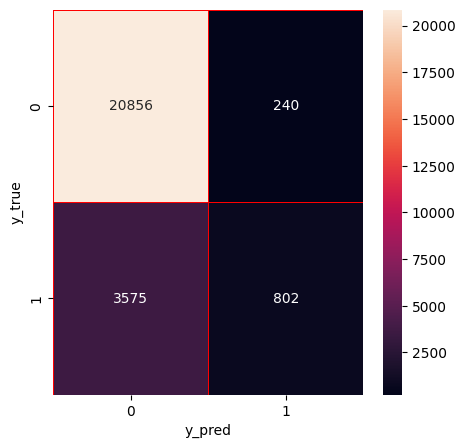

CPU times: total: 3.38 s
Wall time: 336 ms


In [7]:
%%time
# LightGBM algorithm
import lightgbm as lgb
classifier = lgb.LGBMClassifier()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(classification_report(y_test,y_pred))
print("Accuracy: "+str(round(accuracy_score(y_test, y_pred),5)*100)+"%")
print("Precision: "+str(round(precision_score(y_test, y_pred),5)*100)+"%")
print("Recall: "+str(round(recall_score(y_test, y_pred),5)*100)+"%")
print("F1-score: "+str(round(f1_score(y_test, y_pred),5)*100)+"%")

# Plot the confusion matrix
cm=confusion_matrix(y_test,y_pred)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

The F1-score/accuracy of the static LightGBM model is very low, due to the occurance of concept drift (data distribution changes). Therefore, online learning methods that can adapt to concept drift issues should be developed for dynamic data stream analytics.

## Define Basic Learning Functions

### Including the following methods/steps:
1. **Automated Data Balancing**: Continuously evaluates whether the current data is balanced and automatically triggers the Chebyshev Over-Sampling (COS) method to generate synthetic data samples until the data is balanced.
2. **Automated Feature Engineering (AutoFE)**: Uses the Pearson Correlation Coefficient (PCC)-based Select-K-Best method to automatically select and update the best feature set based on the current concept data.
3. **Drift Detection**: Uses Adaptive Windowing (ADWIN) and the Early Drift Detection Method (EDDM) to detect concept drift and trigger feature re-selection.
4. **Model Learning**: Uses an online learning model to continuously learn and predict dynamic data streams. The model is a parameter that can be set using various online learners.

In [8]:
# Import the online learning metrics and algorithms from the River library
import river
from river import metrics, stream, feature_selection, stats, imblearn
from river import tree, ensemble, linear_model, naive_bayes, forest
from river import rules, model_selection, bandit

from river.drift import ADWIN
from river.drift.binary import DDM,EDDM

from collections import Counter, deque

In [9]:
# Define the general adaptive learning function
def adaptive_learning(model, X_train, y_train, X_test, y_test):
    metric = metrics.Accuracy()  # Use accuracy as the metric
    i = 0  # Count the number of evaluated data points
    t = []  # Record the number of evaluated data points
    m = []  # Record the real-time accuracy
    yt = []  # Record all the true labels of the test set
    yp = []  # Record all the predicted labels of the test set

    # Initialize feature selection (keeping top 15 features based on Pearson correlation)
    selector = feature_selection.SelectKBest(similarity=stats.PearsonCorr(), k=15) # 15 can be changed based on the dataset

    # Initialize ChebyshevOverSampler with a simple regressor
    cos = imblearn.ChebyshevOverSampler(regressor=linear_model.LinearRegression())

    # Initialize Drift Detectors
    adwin = ADWIN()  # Detects abrupt changes
    eddm = EDDM()  # Detects gradual drift

    # Adaptive Window Size: Minimum 20, Maximum 1000, or 10% of total samples
    window_size = min(1000, max(20, int(0.1 * len(X_train))))
    drift_window = deque(maxlen=window_size)  # Stores recent drift detections

    # Count class occurrences
    class_counts = Counter(y_train)
    majority_class = max(class_counts, key=class_counts.get)
    minority_class = min(class_counts, key=class_counts.get)

    # Apply ChebyshevOverSampler if imbalance is detected (minority class < 50% of majority)
    if class_counts[minority_class] < 0.5 * class_counts[majority_class]:
        for x, y in stream.iter_pandas(X_train, y_train):
            cos.learn_one(x, y)  # Train ChebyshevOverSampler on real samples

        # Generate synthetic samples until balance is reached
        new_samples = []
        while class_counts[minority_class] < 0.5 * class_counts[majority_class]:
            x_synthetic, y_synthetic = cos.learn_one({}, minority_class)  # Generate a synthetic sample
            new_samples.append((x_synthetic, y_synthetic))
            class_counts[y_synthetic] += 1  # Update class count

        # Convert new samples into a Pandas DataFrame
        X_synthetic = [x for x, _ in new_samples]
        y_synthetic = [y for _, y in new_samples]

        # Concatenate synthetic samples with original dataset
        X_train = X_train.append(X_synthetic, ignore_index=True)
        y_train = y_train.append(y_synthetic, ignore_index=True)

    # Feature selection (initially applied)
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        selector.learn_one(xi1, yi1)

    # Train the model on the balanced dataset
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        xi1 = selector.transform_one(xi1)
        model.learn_one(xi1, yi1)

    # Evaluate on the test set
    for xi, yi in stream.iter_pandas(X_test, y_test):
        xi = selector.transform_one(xi)
        y_pred = model.predict_one(xi)  # Predict the test sample
        model.learn_one(xi, yi)  # Learn the test sample
        metric = metric.update(yi, y_pred)  # Update accuracy

        # Update drift detectors with misclassification error 
        adwin.update(y_pred != yi)  # Detect abrupt drift based on errors
        eddm.update(y_pred != yi)  # Detect gradual drift based on errors

        # Store drift detection results in the sliding window
        drift_window.append((adwin.drift_detected, eddm.drift_detected))

        # Drift triggers if both ADWIN & EDDM detected drift at least once in the past window
        adwin_agreed = any(adwin_detected for adwin_detected, _ in drift_window)
        eddm_agreed = any(eddm_detected for _, eddm_detected in drift_window)

        if adwin_agreed and eddm_agreed:
            print(f"🚨 Confirmed Drift at sample {i}, re-selecting features...")
            selector = feature_selection.SelectKBest(similarity=stats.PearsonCorr(), k=15)  # Reinitialize feature selector

            # Re-train feature selection on available data
            for xi1, yi1 in stream.iter_pandas(X_train, y_train):
                selector.learn_one(xi1, yi1)

            # Reset drift window after handling drift
            drift_window.clear()

        # Store results
        t.append(i)
        m.append(metric.get() * 100)
        yt.append(yi)
        yp.append(y_pred)
        i += 1

    # Print final evaluation metrics
    print("Final Accuracy:", round(metric.get() * 100, 2), "%")

    return t, m



In [10]:
# Define a figure function that shows the real-time accuracy changes
def acc_fig(t, m, name):
    plt.rcParams.update({'font.size': 15})
    plt.figure(1,figsize=(10,6)) 
    sns.set_style("darkgrid")
    plt.clf() 
    plt.plot(t,m,'-b',label='Avg Accuracy: %.2f%%'%(m[-1]))

    plt.legend(loc='best')
    plt.title(name+' on CICIDS2017 dataset', fontsize=15)
    plt.xlabel('Number of samples')
    plt.ylabel('Accuracy (%)')

    plt.draw()

# 1. Automated Data Pre-Processing

🚨 Confirmed Drift at sample 351, re-selecting features...
🚨 Confirmed Drift at sample 2523, re-selecting features...
🚨 Confirmed Drift at sample 19390, re-selecting features...
🚨 Confirmed Drift at sample 22975, re-selecting features...
Final Accuracy: 85.79 %
CPU times: total: 5.94 s
Wall time: 5.96 s


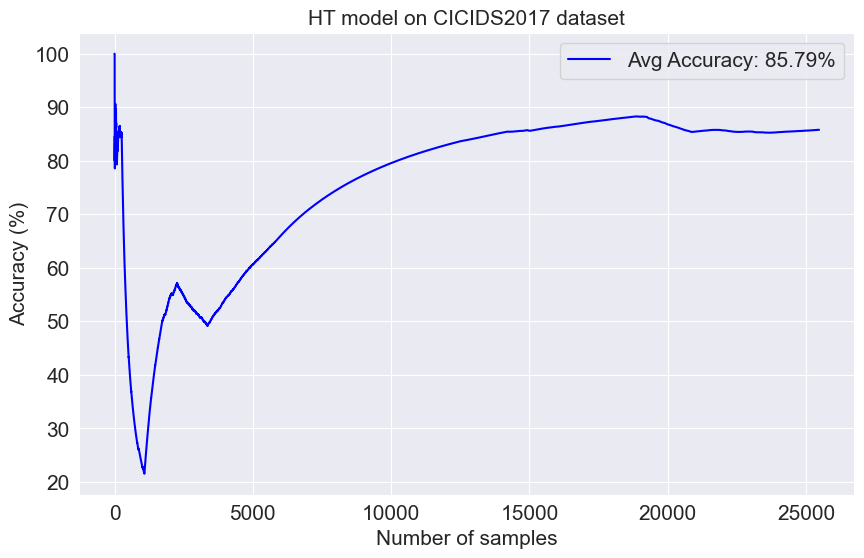

In [11]:
%%time
# Use the Hoeffding Tree (HT) model 
name1 = "HT model"

model1 = tree.HoeffdingTreeClassifier()
t, m1 = adaptive_learning(model1, X_train, y_train, X_test, y_test)
acc_fig(t, m1, name1) # Draw the figure of how the real-time accuracy changes with the number of samples

🚨 Confirmed Drift at sample 287, re-selecting features...
🚨 Confirmed Drift at sample 14335, re-selecting features...
🚨 Confirmed Drift at sample 19327, re-selecting features...
Final Accuracy: 97.83 %
CPU times: total: 45.2 s
Wall time: 45.2 s


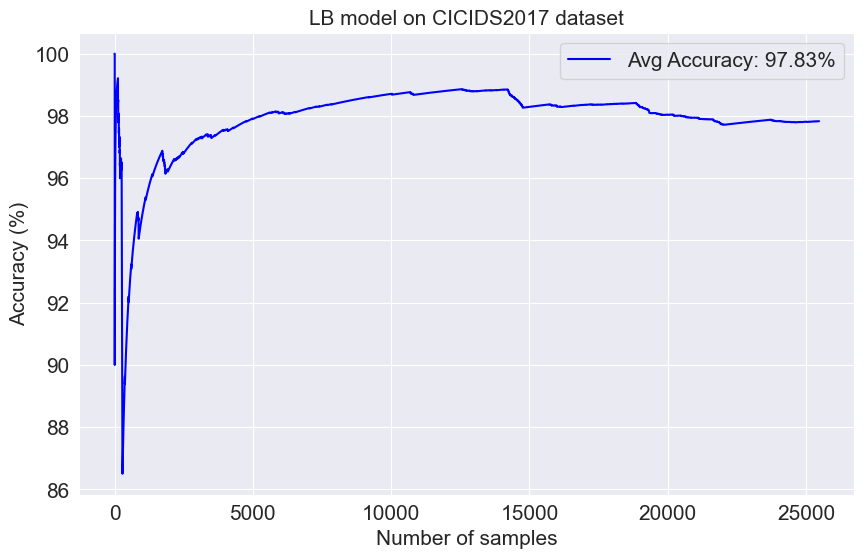

In [12]:
%%time
# Use the Leveraging Bagging (LB) model 
name2 = "LB model"
model2 = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(),n_models=3) # Define the model
t, m2 = adaptive_learning(model2, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m2, name2) # Draw the figure of how the real-time accuracy changes with the number of samples

🚨 Confirmed Drift at sample 14281, re-selecting features...
🚨 Confirmed Drift at sample 19359, re-selecting features...
Final Accuracy: 98.5 %
CPU times: total: 12.7 s
Wall time: 12.7 s


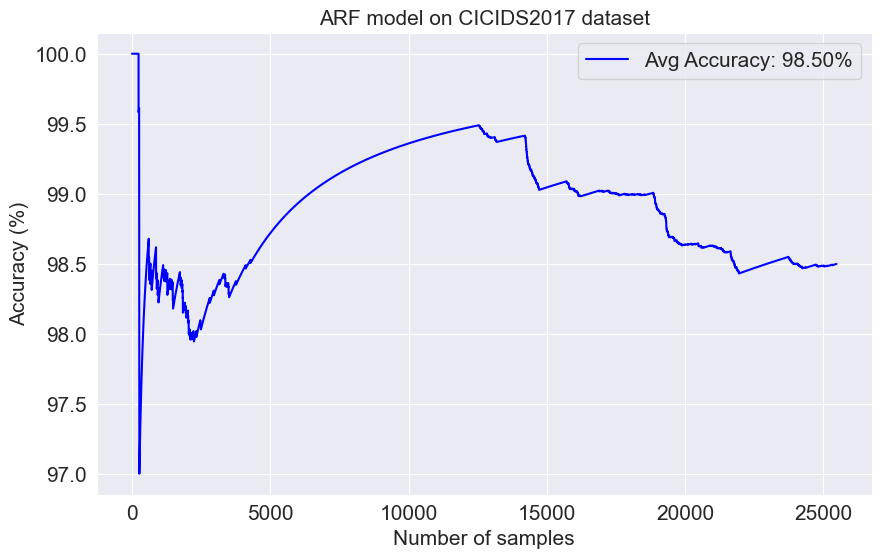

In [13]:
%%time
# Use the Adaptive Random Forest (ARF) model
name3 = "ARF model"
#model3 = ensemble.AdaptiveRandomForestClassifier(n_models = 3) # Define the model
model3 = forest.ARFClassifier(n_models = 3)
t, m3 = adaptive_learning(model3, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m3, name3) # Draw the figure of how the real-time accuracy changes with the number of samples

🚨 Confirmed Drift at sample 14271, re-selecting features...
🚨 Confirmed Drift at sample 19327, re-selecting features...
Final Accuracy: 98.51 %
CPU times: total: 40.4 s
Wall time: 40.4 s


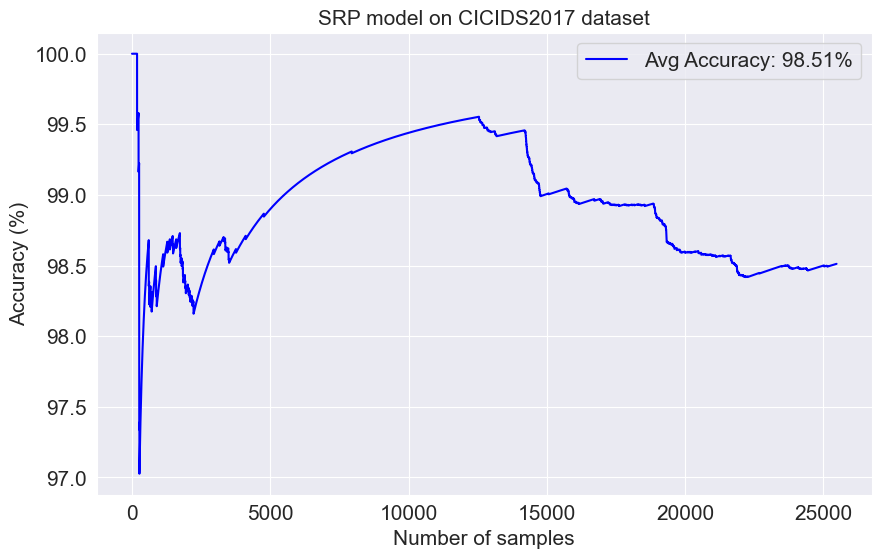

In [14]:
%%time
# Use the Streaming Random Patches (SRP) model with ADWIN drift detector
name4 = "SRP model"
model4 = ensemble.SRPClassifier(n_models = 3) # Define the model
t, m4 = adaptive_learning(model4, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m4, name4) # Draw the figure of how the real-time accuracy changes with the number of samples

🚨 Confirmed Drift at sample 287, re-selecting features...
🚨 Confirmed Drift at sample 14303, re-selecting features...
🚨 Confirmed Drift at sample 19391, re-selecting features...
Final Accuracy: 97.66 %
CPU times: total: 35.3 s
Wall time: 35.4 s


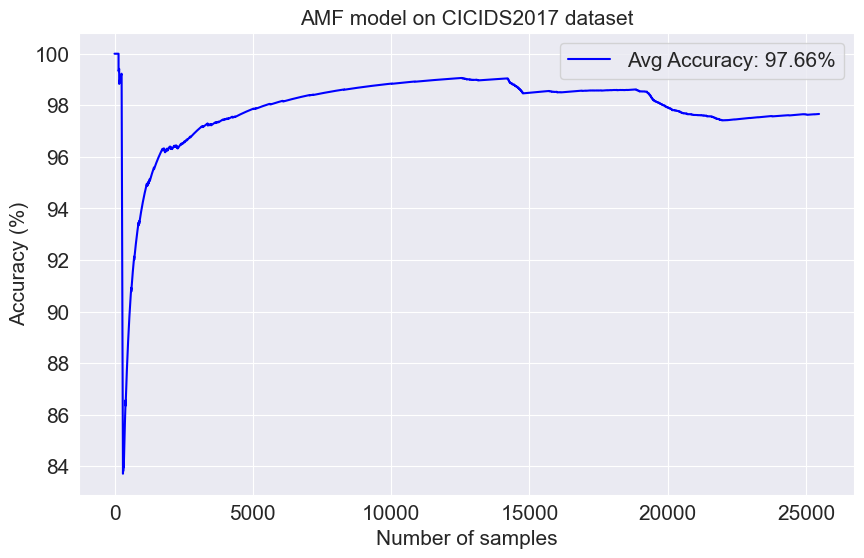

In [15]:
%%time
# Use the Aggregated Mondrian Forest (AMF) model - 2019
name5 = "AMF model"
model5 = forest.AMFClassifier(n_estimators = 3) # Define the model
t, m5 = adaptive_learning(model5, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m5, name5) # Draw the figure of how the real-time accuracy changes with the number of samples

🚨 Confirmed Drift at sample 289, re-selecting features...
🚨 Confirmed Drift at sample 19295, re-selecting features...
🚨 Confirmed Drift at sample 21727, re-selecting features...
🚨 Confirmed Drift at sample 22079, re-selecting features...
🚨 Confirmed Drift at sample 24431, re-selecting features...
Final Accuracy: 94.46 %
CPU times: total: 10.4 s
Wall time: 10.4 s


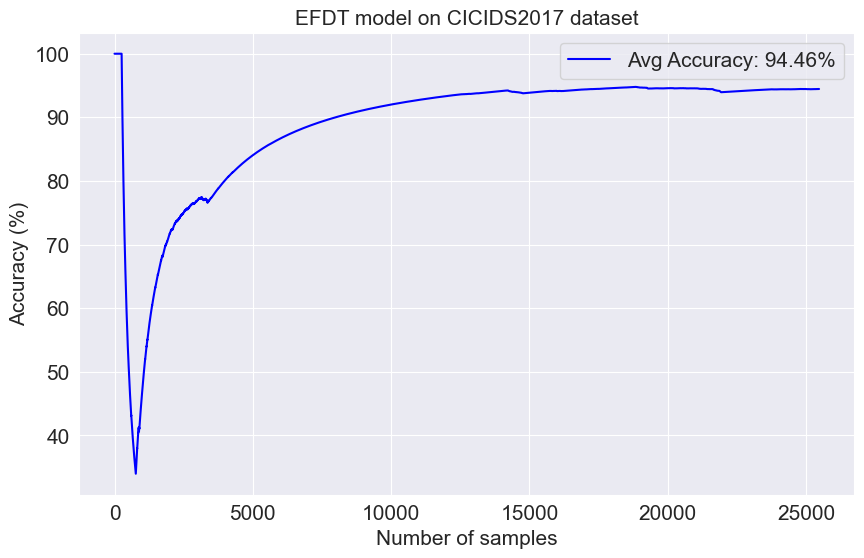

In [16]:
%%time
# Use the Extremely Fast Decision Tree (EFDT) model - 2018
name6 = "EFDT model"
# model6 = tree.ExtremelyFastDecisionTreeClassifier() # Define the model
model6 = tree.HoeffdingAdaptiveTreeClassifier(drift_detector=DDM()) # Define the model
t, m6 = adaptive_learning(model6, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m6, name6) # Draw the figure of how the real-time accuracy changes with the number of samples


🚨 Confirmed Drift at sample 351, re-selecting features...
🚨 Confirmed Drift at sample 1791, re-selecting features...
🚨 Confirmed Drift at sample 2036, re-selecting features...
🚨 Confirmed Drift at sample 2268, re-selecting features...
🚨 Confirmed Drift at sample 19376, re-selecting features...
🚨 Confirmed Drift at sample 19519, re-selecting features...
🚨 Confirmed Drift at sample 21695, re-selecting features...
🚨 Confirmed Drift at sample 21951, re-selecting features...
🚨 Confirmed Drift at sample 24454, re-selecting features...
Final Accuracy: 82.8 %
CPU times: total: 5.98 s
Wall time: 5.97 s


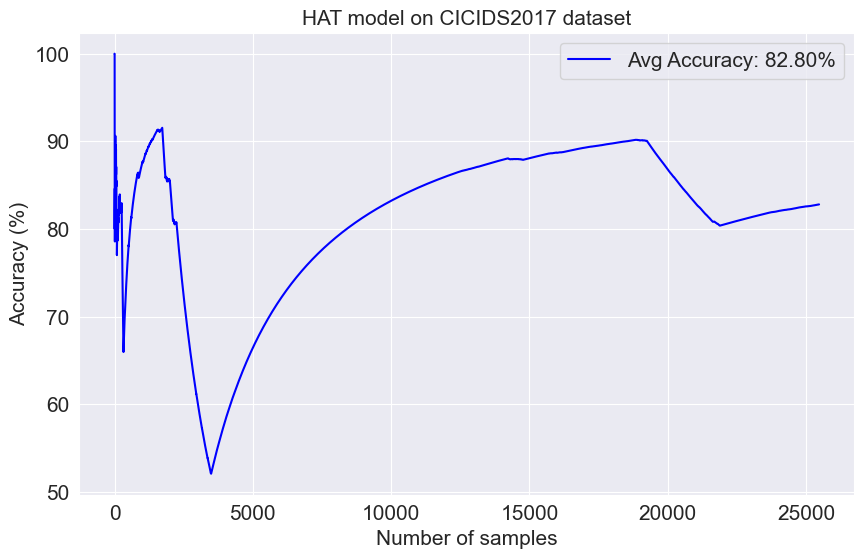

In [17]:
%%time
# Use the HAT model - 2010
name7 = "HAT model"
model7 = tree.HoeffdingAdaptiveTreeClassifier() # Define the model
t, m7 = adaptive_learning(model7, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m7, name7) # Draw the figure of how the real-time accuracy changes with the number of samples


[1]	3 removed	4 left	952 iterations	budget used: 6664	budget left: 13336	best Accuracy: 98.53%
[2]	2 removed	2 left	1666 iterations	budget used: 13328	budget left: 6672	best Accuracy: 98.92%
[3]	1 removed	1 left	3333 iterations	budget used: 19994	budget left: 6	best Accuracy: 98.53%
🚨 Confirmed Drift at sample 14335, re-selecting features...
🚨 Confirmed Drift at sample 19359, re-selecting features...
Final Accuracy: 98.45 %
CPU times: total: 56.2 s
Wall time: 56.3 s


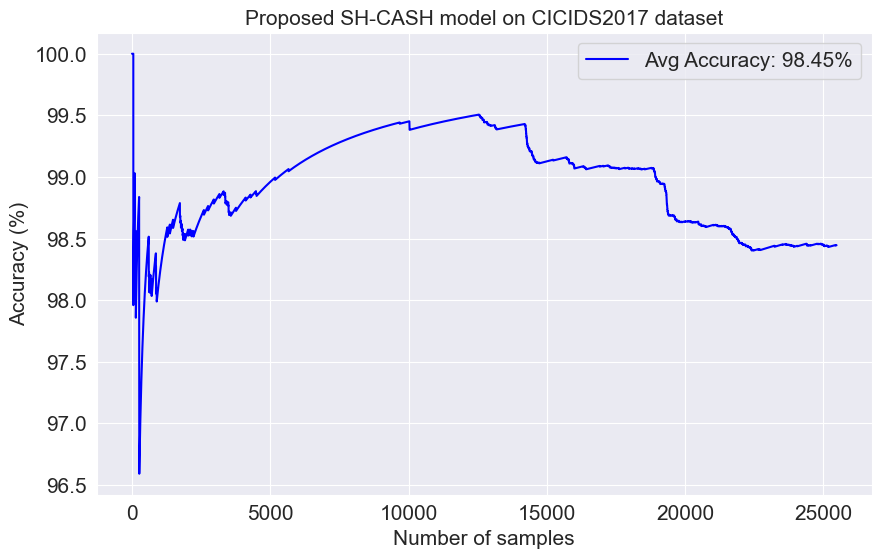

In [18]:
%%time
# Use the basic proposed SH-CASH model (without model optimization)

model_list = [model1, model2, model3, model4, model5, model6, model7]

name0 = "Proposed SH-CASH model"
model0 = model_selection.SuccessiveHalvingClassifier( # Define the SH-CASH model
    model_list, # List of models to be compared
    metric=metrics.Accuracy(), # Metric to be used
    budget=20000, # Total number of samples to be evaluated
    eta=2, # Reduction factor
    verbose=True # Print the progress
)
t, m0 = adaptive_learning(model0, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m0, name0) # Draw the figure of how the real-time accuracy changes with the number of samples


# Hyperparameter Optimization

In [20]:
# Optimized the hyperparameters of the ARF model
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Define the objective function for hyperparameter tuning
def objective(params):
    params = {
        'n_models': int(params['n_models']),  # Ensure integer value
        'drift_detector': ADWIN() if params['drift_detector'] == 'ADWIN' else EDDM()
    }

    # Initialize ARFClassifier with the tuned parameters
    clf = forest.ARFClassifier(n_models=params['n_models'], drift_detector=params['drift_detector'])

    # Run adaptive learning with this model
    t, m = adaptive_learning(clf, X_train, y_train, X_test, y_test)

    # Optimization goal: maximize accuracy (so we minimize negative accuracy)
    return {'loss': -m[-1], 'status': STATUS_OK}

# Define the hyperparameter search space
space = {
    'n_models': hp.quniform('n_models', 2, 10, 1),  # Search over 2 to 10 models
    'drift_detector': hp.choice('drift_detector', ['ADWIN', 'EDDM'])  # Choose between ADWIN and EDDM
}

# Run Hyperopt for optimization
best1 = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=10)

# Print the best-found hyperparameters
print("ARF: Hyperopt estimated optimum {}".format(best1))


🚨 Confirmed Drift at sample 14303, re-selecting features...
🚨 Confirmed Drift at sample 21983, re-selecting features...
🚨 Confirmed Drift at sample 24255, re-selecting features...
Final Accuracy:                                       
98.35                                                 
%                                                     
🚨 Confirmed Drift at sample 14559, re-selecting features...                    
🚨 Confirmed Drift at sample 21918, re-selecting features...                    
Final Accuracy:                                                                 
98.28                                                                           
%                                                                               
🚨 Confirmed Drift at sample 14271, re-selecting features...                    
🚨 Confirmed Drift at sample 19519, re-selecting features...                    
🚨 Confirmed Drift at sample 21951, re-selecting features...                    
Final Accura

In [21]:
# optimize the hyperparameters of the SRP model

# Define the objective function
def objective(params):
    params = {
        'n_models': int(params['n_models']), 
        'drift_detector': ADWIN() if params['drift_detector'] == 'ADWIN' else EDDM()
    }
    clf = ensemble.SRPClassifier( **params)
    
    t, m = adaptive_learning(clf, X_train, y_train, X_test, y_test)
    
    return {'loss':-m[-1], 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'n_models': hp.quniform('n_models', 2, 10, 1),
    'drift_detector': hp.choice('drift_detector', ['ADWIN', 'EDDM'])  # Choose between ADWIN and EDDM
}

# Detect the optimal hyperparameter values
best2 = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=10)
print("SRP: Hyperopt estimated optimum {}".format(best2))

🚨 Confirmed Drift at sample 14271, re-selecting features...
Final Accuracy:                                       
98.85                                                 
%                                                     
🚨 Confirmed Drift at sample 14271, re-selecting features...                   
🚨 Confirmed Drift at sample 19391, re-selecting features...                   
Final Accuracy:                                                                
98.51                                                                          
%                                                                              
🚨 Confirmed Drift at sample 14275, re-selecting features...                   
🚨 Confirmed Drift at sample 18559, re-selecting features...                   
Final Accuracy:                                                                
98.67                                                                          
%                                                          

🚨 Confirmed Drift at sample 14303, re-selecting features...
🚨 Confirmed Drift at sample 19391, re-selecting features...
Final Accuracy: 98.65 %
CPU times: total: 31.6 s
Wall time: 31.7 s


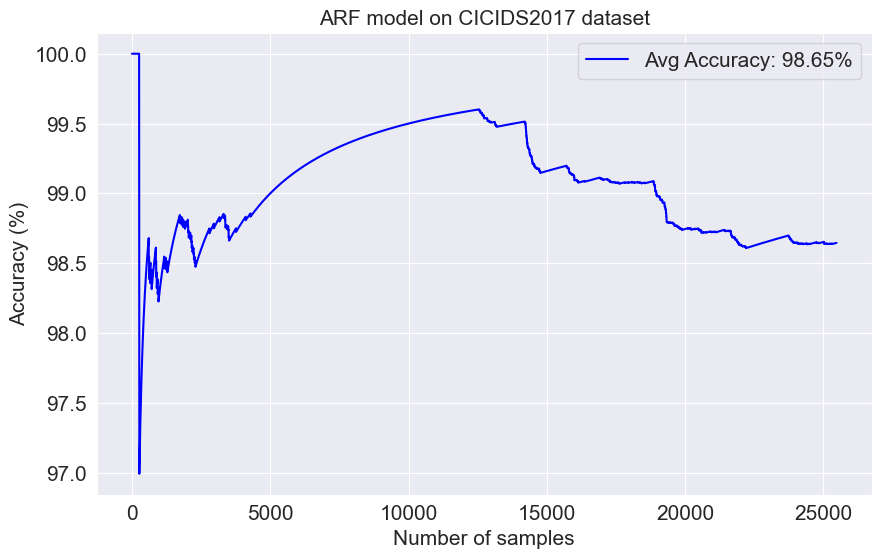

In [ ]:
%%time
# Use the Adaptive Random Forest (ARF) model
name8 = "Optimized ARF model"

drift_detector = ADWIN() if best1['drift_detector'] == 1 else EDDM()

model8 = forest.ARFClassifier(n_models=int(best1['n_models']), drift_detector=drift_detector)
t, m8 = adaptive_learning(model8, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m8, name8) # Draw the figure of how the real-time accuracy changes with the number of samples

🚨 Confirmed Drift at sample 14320, re-selecting features...
Final Accuracy: 98.79 %
CPU times: total: 2min 3s
Wall time: 2min 3s


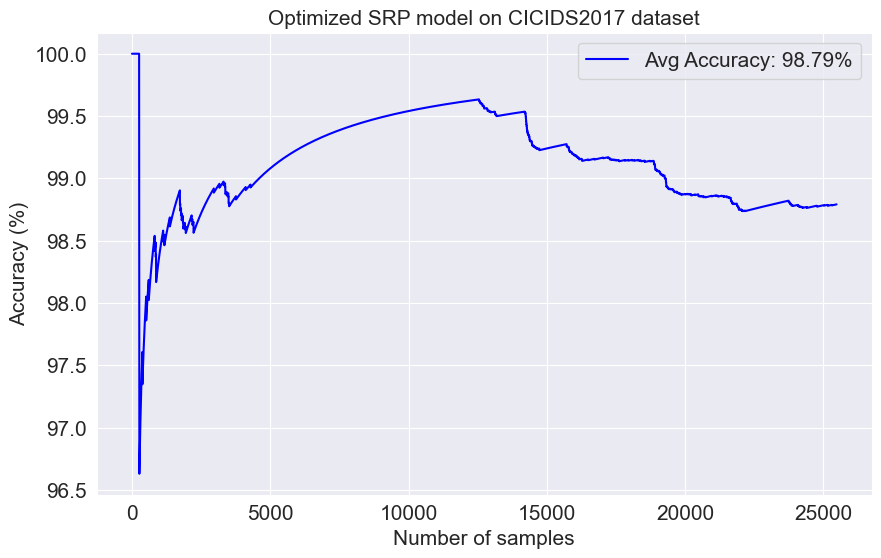

In [ ]:
%%time
# Use the Streaming Random Patches (SRP) model
name9 = "Optimized SRP model"

drift_detector = ADWIN() if best2['drift_detector'] == 1 else EDDM()

model9 = ensemble.SRPClassifier(n_models=int(best2['n_models']), drift_detector=drift_detector)
t, m9 = adaptive_learning(model9, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m9, name9) # Draw the figure of how the real-time accuracy changes with the number of samples

[1]	4 removed	5 left	1111 iterations	budget used: 9999	budget left: 30001	best Accuracy: 100.00%
[2]	2 removed	3 left	2000 iterations	budget used: 19999	budget left: 20001	best Accuracy: 100.00%
[3]	1 removed	2 left	3333 iterations	budget used: 29998	budget left: 10002	best Accuracy: 99.85%
[4]	1 removed	1 left	5000 iterations	budget used: 39998	budget left: 2	best Accuracy: 99.82%
🚨 Confirmed Drift at sample 19007, re-selecting features...
Final Accuracy: 98.59 %
CPU times: total: 1min 18s
Wall time: 1min 18s


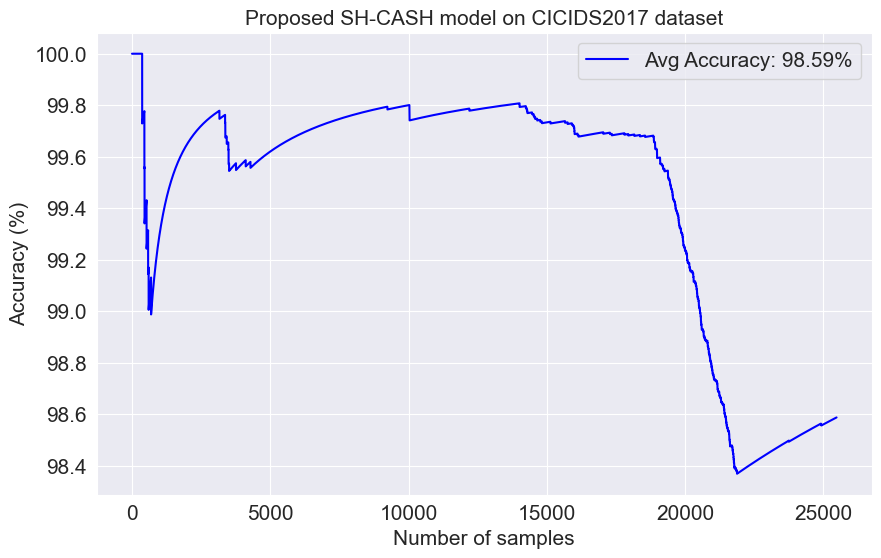

In [ ]:
%%time
# Use the proposed SH-CASH model (Method 1: consider all models)
model_list = [model1, model2, model3, model4, model5, model6, model7, model8, model9]

name10 = "Proposed SH-CASH model"
model10 = model_selection.SuccessiveHalvingClassifier( # Define the SH-CASH model
    model_list, # List of models to be compared
    metric=metrics.Accuracy(), # Metric to be used
    budget=40000, # Total number of samples to be evaluated
    eta=2, # Reduction factor
    verbose=True # Print the progress
)
t, m10 = adaptive_learning(model10, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m10, name10) # Draw the figure of how the real-time accuracy changes with the number of samples


[1]	2 removed	2 left	5000 iterations	budget used: 20000	budget left: 20000	best Accuracy: 99.56%
[2]	1 removed	1 left	10000 iterations	budget used: 40000	budget left: 0	best Accuracy: 99.62%
🚨 Confirmed Drift at sample 14303, re-selecting features...
🚨 Confirmed Drift at sample 19359, re-selecting features...
Final Accuracy: 98.79 %
CPU times: total: 2min 28s
Wall time: 2min 28s


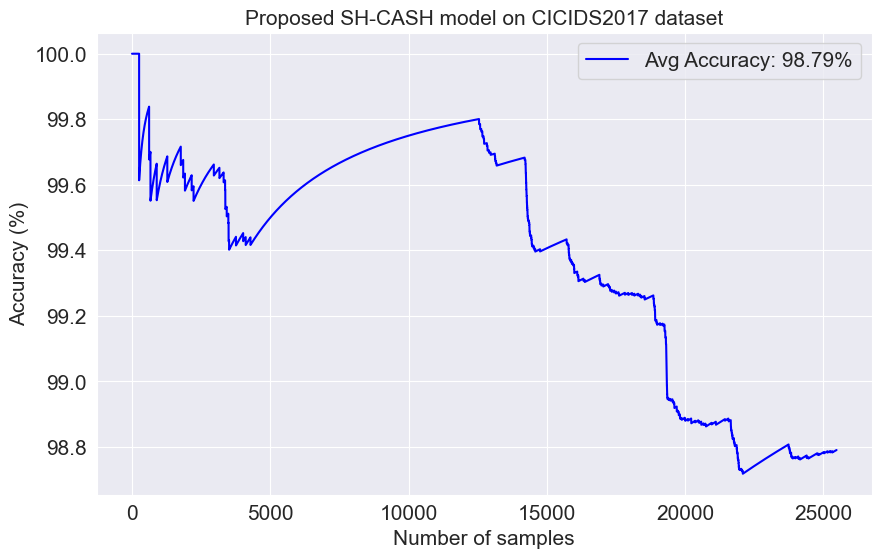

In [ ]:
%%time
# Use the proposed SH-CASH model (Method 2: consider the two best-performing base models and their optimized versions)
model_list = [model3, model8, model4, model9]

name10 = "Proposed SH-CASH model"
model10 = model_selection.SuccessiveHalvingClassifier( # Define the SH-CASH model
    model_list, # List of models to be compared
    metric=metrics.Accuracy(), # Metric to be used
    budget=40000, # Total number of samples to be evaluated
    eta=2, # Reduction factor
    verbose=True # Print the progress
)
t, m10 = adaptive_learning(model10, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m10, name10) # Draw the figure of how the real-time accuracy changes with the number of samples


🚨 Confirmed Drift at sample 14271, re-selecting features...
[1]	1 removed	1 left	20000 iterations	budget used: 40000	budget left: 0	best Accuracy: 99.02%
Final Accuracy: 98.82 %
CPU times: total: 2min 37s
Wall time: 2min 37s


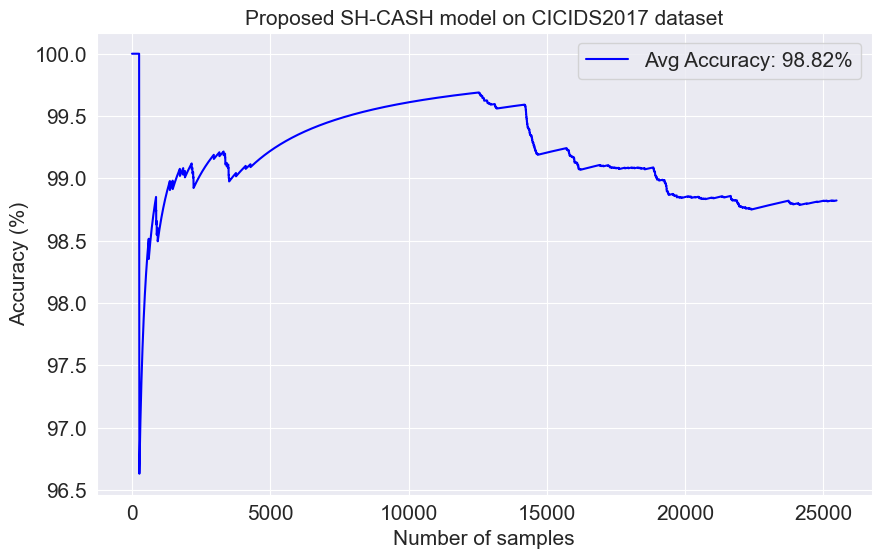

In [ ]:
%%time
# Use the proposed SH-CASH model (Method 3: consider the optimized versions of the two best-performing base models only)
model_list = [model8, model9]

name10 = "Proposed SH-CASH model"
model10 = model_selection.SuccessiveHalvingClassifier( # Define the SH-CASH model
    model_list, # List of models to be compared
    metric=metrics.Accuracy(), # Metric to be used
    budget=40000, # Total number of samples to be evaluated
    eta=2, # Reduction factor
    verbose=True # Print the progress
)
t, m10 = adaptive_learning(model10, X_train, y_train, X_test, y_test) # Learn the model on the dataset
acc_fig(t, m10, name10) # Draw the figure of how the real-time accuracy changes with the number of samples


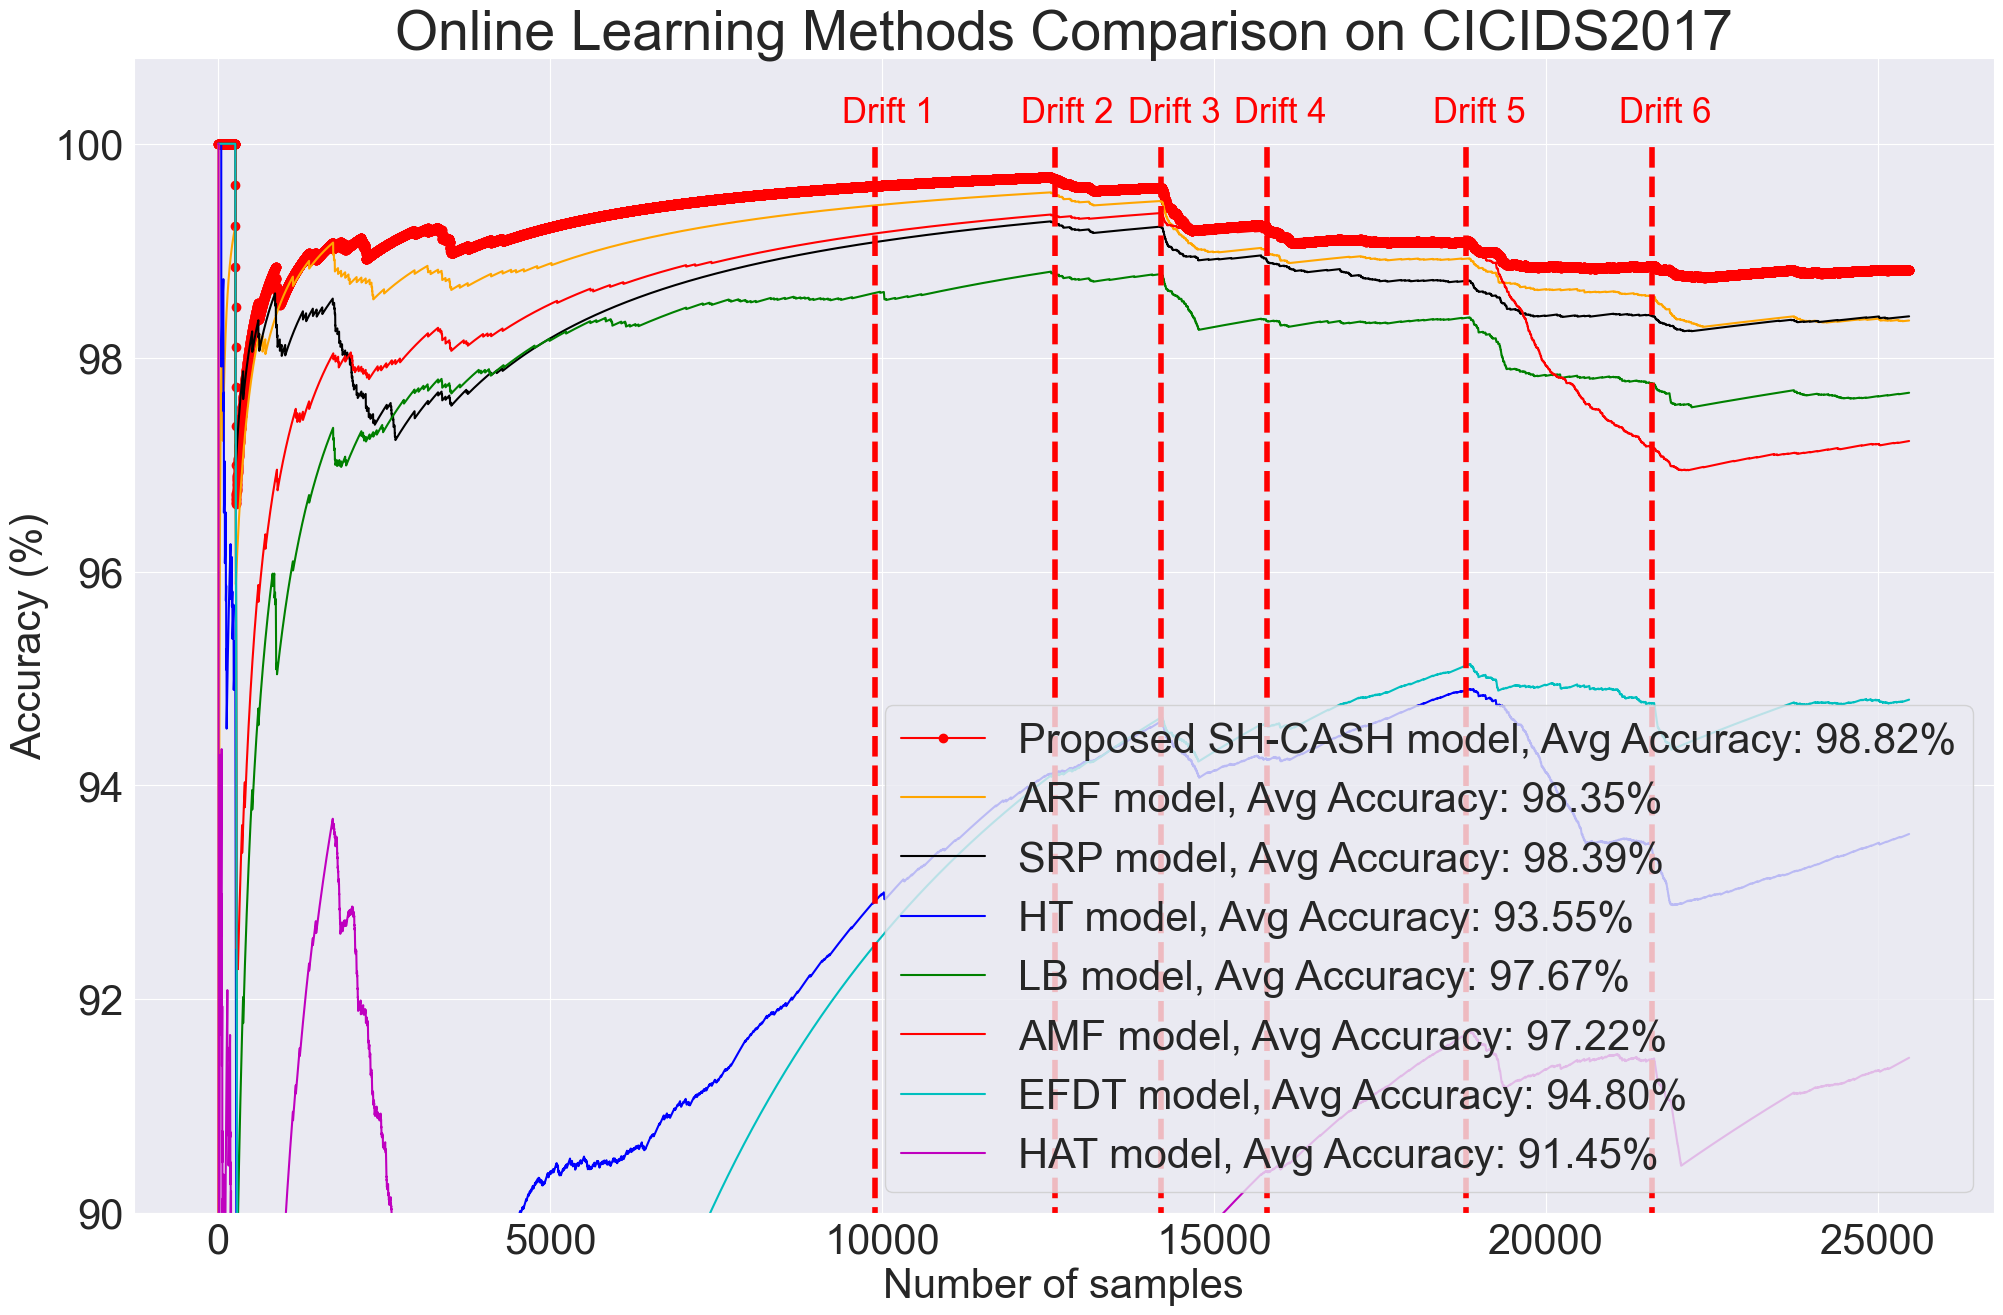

In [ ]:
# Draw a comprehensive figure to compare the performance of all models
plt.rcParams.update({'font.size': 30})
plt.figure(1,figsize=(24,15)) 
sns.set_style("darkgrid")
plt.clf() 

# Plot the accuracy change of each learner
plt.plot(t,m10,'-ro',label=name10+', Avg Accuracy: %.2f%%'%(m10[-1]))
plt.plot(t,m3,'orange',label=name3+', Avg Accuracy: %.2f%%'%(m3[-1]))
plt.plot(t,m4,'black',label=name4+', Avg Accuracy: %.2f%%'%(m4[-1]))

plt.plot(t,m1,'-b',label=name1+', Avg Accuracy: %.2f%%'%(m1[-1]))
plt.plot(t,m2,'-g',label=name2+', Avg Accuracy: %.2f%%'%(m2[-1]))

plt.plot(t,m5,'-r',label=name5+', Avg Accuracy: %.2f%%'%(m5[-1]))
plt.plot(t,m6,'-c',label=name6+', Avg Accuracy: %.2f%%'%(m6[-1]))
plt.plot(t,m7,'-m',label=name7+', Avg Accuracy: %.2f%%'%(m7[-1]))
# plt.plot(t,m8,'-y',label=name8+', Avg Accuracy: %.2f%%'%(m8[-1]))


# Draw the drift points/time
dr = [0,9900,12600, 14200,15800,18800,21600]
for i in range(len(dr)):
    if i!=0:
        plt.text(dr[i]-500, 100.2, 'Drift '+str(i), c = "red", fontsize = 25)
        plt.vlines(dr[i], 0, 100, colors = "red", linewidth=4, linestyles = "dashed")
        
plt.legend(loc='lower right')
plt.ylim(90, 100.8)
plt.title('Online Learning Methods Comparison on CICIDS2017', fontsize=40)
plt.xlabel('Number of samples')
plt.ylabel('Accuracy (%)')

plt.draw()